In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import gpflow

from scipy import stats
from scipy.linalg import eig

gpflow.config.set_default_float(np.float64)

RANDOM_SEED = 123
N_MESH = 250

# Start with 500 while developing; increase after validating the code.
N_IPM_DRAWS = 500

/opt/anaconda3/envs/gpflow-env/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
DATA_PATH = Path("gp_sample250.csv")

data = pd.read_csv(DATA_PATH)


In [ ]:
posterior_candidates = [
    Path("train_deeprv_v2/N_250/gp_posterior_samples.npz"),
]

POSTERIOR_PATHS = {
    "gp": Path(
        "train_deeprv_v2/N_250/"
        "gp_posterior_samples.npz"
    ),
    "deeprv": Path(
        "train_deeprv_v2/N_250/"
        "deeprv_posterior_samples.npz"
    ),
}

posteriors = {}

for method, path in POSTERIOR_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(
            f"{method} posterior not found: {path}"
        )

    with np.load(path, allow_pickle=False) as file:
        posteriors[method] = {
            key: file[key]
            for key in file.files
        }

survival__mu: (8000, 239)
survival__r: (8000,)
survival__ls: (8000,)
survival__beta: (8000,)
survival__s_obs: (239, 1)
reproduction__mu: (8000, 250)
reproduction__r: (8000,)
reproduction__ls: (8000,)
reproduction__beta: (8000,)
reproduction__s_obs: (250, 1)
seed__mu: (8000, 11)
seed__r: (8000,)
seed__ls: (8000,)
seed__beta: (8000,)
seed__s_obs: (11, 1)
growth__mu: (8000, 111)
growth__r: (8000,)
growth__ls: (8000,)
growth__obs_noise: (8000,)
growth__beta: (8000,)
growth__s_obs: (111, 1)
recruitment__probability: ()
recruitment__mean: ()
recruitment__sd: ()
gp__jitter: ()


In [4]:
vital_rates = [
    "survival",
    "reproduction",
    "seed",
    "growth",
]

required_keys = [
    "survival__mu",
    "survival__r",
    "survival__ls",
    "survival__beta",
    "survival__s_obs",
    "reproduction__mu",
    "reproduction__r",
    "reproduction__ls",
    "reproduction__beta",
    "reproduction__s_obs",
    "seed__mu",
    "seed__r",
    "seed__ls",
    "seed__beta",
    "seed__s_obs",
    "growth__mu",
    "growth__r",
    "growth__ls",
    "growth__beta",
    "growth__obs_noise",
    "growth__s_obs",
    "recruitment__probability",
    "recruitment__mean",
    "recruitment__sd",
    "gp__jitter",
]

missing_keys = [
    key for key in required_keys
    if key not in posterior
]

if missing_keys:
    raise KeyError(
        f"Missing posterior arrays: {missing_keys}"
    )

for rate in vital_rates:
    n_draws = posterior[f"{rate}__mu"].shape[0]
    n_locations = posterior[f"{rate}__mu"].shape[1]
    n_saved_locations = posterior[f"{rate}__s_obs"].shape[0]

    if n_locations != n_saved_locations:
        raise ValueError(
            f"{rate}: mu contains {n_locations} locations, "
            f"but s_obs contains {n_saved_locations}."
        )

    print(
        f"{rate}: {n_draws} posterior draws, "
        f"{n_locations} observed locations"
    )

survival: 8000 posterior draws, 239 observed locations
reproduction: 8000 posterior draws, 250 observed locations
seed: 8000 posterior draws, 11 observed locations
growth: 8000 posterior draws, 111 observed locations


In [5]:
recruit_probability = float(
    np.asarray(
        posterior["recruitment__probability"]
    ).item()
)

recruit_mean = float(
    np.asarray(
        posterior["recruitment__mean"]
    ).item()
)

recruit_sd = float(
    np.asarray(
        posterior["recruitment__sd"]
    ).item()
)

jitter = float(
    np.asarray(
        posterior["gp__jitter"]
    ).item()
)

observed_sizes = [
    data["z"].dropna().to_numpy(dtype=np.float64)
]

if "z1" in data.columns:
    observed_sizes.append(
        data["z1"].dropna().to_numpy(dtype=np.float64)
    )

observed_sizes = np.concatenate(observed_sizes)

# Include approximately all of the recruit-size distribution.
lower_from_recruits = recruit_mean - 4.0 * recruit_sd
upper_from_recruits = recruit_mean + 4.0 * recruit_sd

boundary_margin = 0.5

lower_bound = (
    min(observed_sizes.min(), lower_from_recruits)
    - boundary_margin
)

upper_bound = (
    max(observed_sizes.max(), upper_from_recruits)
    + boundary_margin
)

mesh_width = (
    upper_bound - lower_bound
) / N_MESH

# Midpoint-rule mesh
mesh = (
    lower_bound
    + (np.arange(N_MESH) + 0.5) * mesh_width
)

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Mesh width:", mesh_width)
print("Number of mesh points:", len(mesh))

Lower bound: -3.5670177374260144
Upper bound: 4.287296360637365
Mesh width: 0.03141725639225352
Number of mesh points: 250


In [6]:
def predict_latent_moments_gpflow(
    s_obs,
    mu_obs,
    mesh,
    kernel_variance,
    kernel_lengthscale,
    jitter,
):
    """
    Condition one MCMC-sampled latent GP on a new mesh.

    mu_obs is the sampled zero-mean latent function at s_obs.
    beta is therefore not included here.
    """
    X = np.asarray(
        s_obs,
        dtype=np.float64,
    ).reshape(-1, 1)

    Y = np.asarray(
        mu_obs,
        dtype=np.float64,
    ).reshape(-1, 1)

    Xnew = np.asarray(
        mesh,
        dtype=np.float64,
    ).reshape(-1, 1)

    kernel = gpflow.kernels.SquaredExponential(
        variance=float(kernel_variance),
        lengthscales=float(kernel_lengthscale),
    )

    # The GPR is only being used for GP conditioning.
    model = gpflow.models.GPR(
        data=(X, Y),
        kernel=kernel,
        mean_function=None,
        noise_variance=float(jitter),
    )

    latent_mean, latent_variance = model.predict_f(Xnew)

    latent_mean = latent_mean.numpy()[:, 0]
    latent_variance = latent_variance.numpy()[:, 0]

    # Remove tiny negative values caused by numerical precision.
    latent_variance = np.maximum(
        latent_variance,
        0.0,
    )

    return latent_mean, latent_variance

In [7]:
def likelihood_predictive_moments(
    likelihood,
    Xnew,
    latent_mean,
    latent_variance,
):
    """
    Pass latent GP moments through a GPflow likelihood.
    """
    Fmu = tf.convert_to_tensor(
        latent_mean.reshape(-1, 1),
        dtype=gpflow.default_float(),
    )

    Fvar = tf.convert_to_tensor(
        latent_variance.reshape(-1, 1),
        dtype=gpflow.default_float(),
    )

    Xnew_tf = tf.convert_to_tensor(
        np.asarray(Xnew).reshape(-1, 1),
        dtype=gpflow.default_float(),
    )

    try:
        # Current GPflow interface
        y_mean, y_variance = (
            likelihood.predict_mean_and_var(
                Xnew_tf,
                Fmu,
                Fvar,
            )
        )
    except TypeError:
        # Compatibility with older GPflow versions
        y_mean, y_variance = (
            likelihood.predict_mean_and_var(
                Fmu,
                Fvar,
            )
        )

    return (
        y_mean.numpy()[:, 0],
        y_variance.numpy()[:, 0],
    )

In [8]:
def predict_vital_rate_draw(
    posterior,
    rate,
    draw_index,
    mesh,
    jitter,
):
    """
    Calculate predictive response moments for one MCMC draw.
    """
    latent_mean, latent_variance = (
        predict_latent_moments_gpflow(
            s_obs=posterior[f"{rate}__s_obs"],
            mu_obs=posterior[f"{rate}__mu"][draw_index],
            mesh=mesh,
            kernel_variance=posterior[f"{rate}__r"][draw_index],
            kernel_lengthscale=posterior[f"{rate}__ls"][draw_index],
            jitter=jitter,
        )
    )

    beta = float(
        posterior[f"{rate}__beta"][draw_index]
    )

    # Stored mu excludes the intercept.
    latent_mean = latent_mean + beta

    if rate in {"survival", "reproduction"}:
        likelihood = gpflow.likelihoods.Bernoulli(
            invlink=tf.sigmoid
        )

    elif rate == "seed":
        likelihood = gpflow.likelihoods.Poisson()

    elif rate == "growth":
        # NumPyro obs_noise is a standard deviation, whereas
        # GPflow Gaussian expects a variance.
        obs_noise = float(
            posterior["growth__obs_noise"][draw_index]
        )

        likelihood = gpflow.likelihoods.Gaussian(
            variance=obs_noise**2
        )

    else:
        raise ValueError(
            f"Unknown vital rate: {rate}"
        )

    response_mean, response_variance = (
        likelihood_predictive_moments(
            likelihood=likelihood,
            Xnew=mesh,
            latent_mean=latent_mean,
            latent_variance=latent_variance,
        )
    )

    return {
        "latent_mean": latent_mean,
        "latent_variance": latent_variance,
        "response_mean": response_mean,
        "response_variance": response_variance,
    }

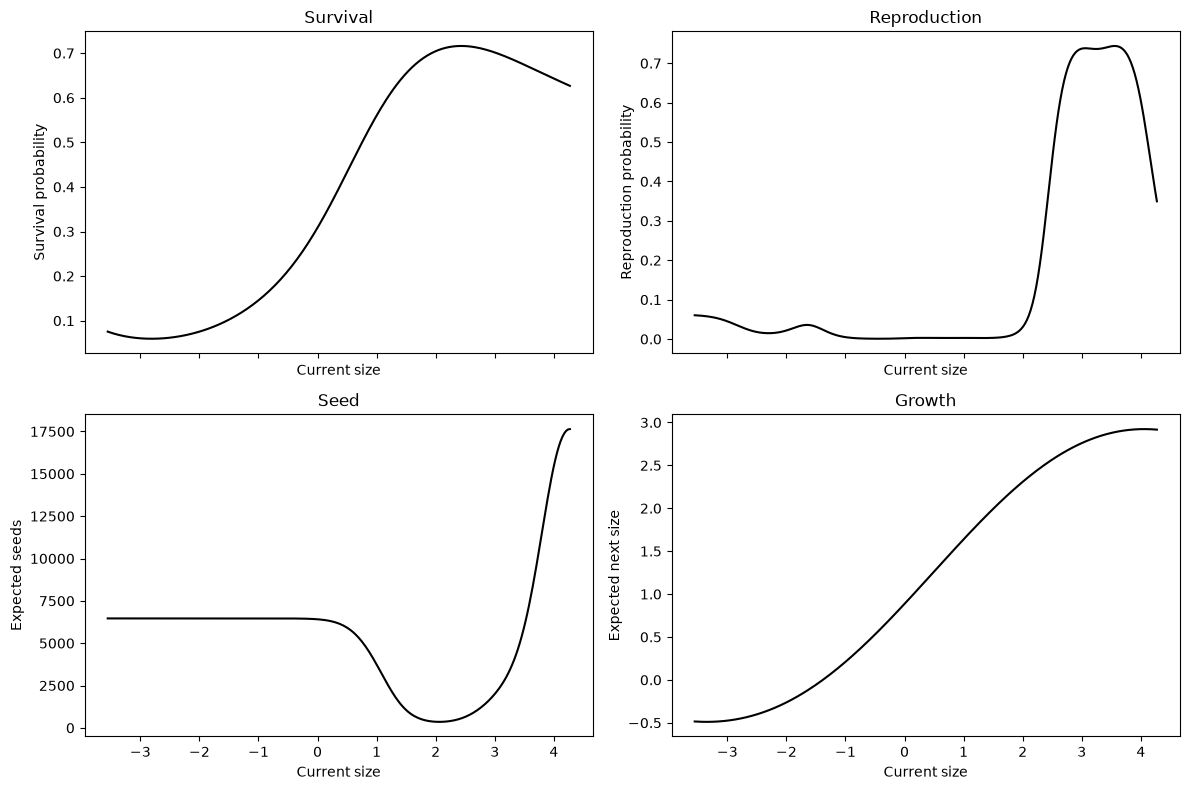

In [9]:
test_draw = 0

test_predictions = {
    rate: predict_vital_rate_draw(
        posterior=posterior,
        rate=rate,
        draw_index=test_draw,
        mesh=mesh,
        jitter=jitter,
    )
    for rate in vital_rates
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
)

for rate, ax in zip(vital_rates, axes.ravel()):
    prediction = test_predictions[rate]

    ax.plot(
        mesh,
        prediction["response_mean"],
        color="black",
    )

    ax.set_title(rate.capitalize())
    ax.set_xlabel("Current size")

axes[0, 0].set_ylabel("Survival probability")
axes[0, 1].set_ylabel("Reproduction probability")
axes[1, 0].set_ylabel("Expected seeds")
axes[1, 1].set_ylabel("Expected next size")

plt.tight_layout()
plt.show()

In [10]:
def recruit_size_density(
    z_next,
    recruit_mean,
    recruit_sd,
):
    return stats.norm.pdf(
        z_next,
        loc=recruit_mean,
        scale=recruit_sd,
    )

In [11]:
def build_ipm_kernel(
    mesh,
    mesh_width,
    survival,
    reproduction,
    seed_mean,
    growth_mean,
    growth_variance,
    recruit_probability,
    recruit_mean,
    recruit_sd,
):
    """
    Construct P, F and K for one posterior draw.

    Rows correspond to next size z'.
    Columns correspond to current size z.
    """
    z_next = mesh[:, None]

    growth_sd = np.sqrt(
        np.maximum(growth_variance, 0.0)
    )

    growth_density = stats.norm.pdf(
        z_next,
        loc=growth_mean[None, :],
        scale=growth_sd[None, :],
    )

    recruit_density = recruit_size_density(
        z_next,
        recruit_mean,
        recruit_sd,
    )

    P_density = (
        (1.0 - reproduction)[None, :]
        * survival[None, :]
        * growth_density
    )

    F_density = (
        reproduction[None, :]
        * seed_mean[None, :]
        * recruit_probability
        * recruit_density
    )

    # Midpoint quadrature
    P = mesh_width * P_density
    F = mesh_width * F_density
    K = P + F

    # Approximate probability retained inside the IPM bounds.
    growth_mass = (
        mesh_width
        * growth_density.sum(axis=0)
    )

    recruit_mass = float(
        mesh_width
        * recruit_density.sum()
    )

    return {
        "P": P,
        "F": F,
        "K": K,
        "growth_mass": growth_mass,
        "recruit_mass": recruit_mass,
    }

In [12]:
def normalize_positive_eigenvector(vector):
    vector = np.real(vector)

    if vector.sum() < 0:
        vector = -vector

    # Remove tiny negative numerical values.
    vector = np.maximum(vector, 0.0)

    total = vector.sum()

    if total <= 0:
        raise ValueError(
            "Could not normalize eigenvector."
        )

    return vector / total


def summarize_ipm_kernel(K, P, F, mesh):
    eigenvalues, left_vectors, right_vectors = eig(
        K,
        left=True,
        right=True,
    )

    dominant_index = np.argmax(
        eigenvalues.real
    )

    lambda_value = float(
        eigenvalues[dominant_index].real
    )

    stable_distribution = (
        normalize_positive_eigenvector(
            right_vectors[:, dominant_index]
        )
    )

    reproductive_value = np.real(
        left_vectors[:, dominant_index]
    )

    if reproductive_value @ stable_distribution < 0:
        reproductive_value = -reproductive_value

    reproductive_value = np.maximum(
        reproductive_value,
        0.0,
    )

    # Scale so that v.T @ w = 1.
    reproductive_value /= (
        reproductive_value
        @ stable_distribution
    )

    mean_stable_size = float(
        stable_distribution @ mesh
    )

    survival_growth_contribution = float(
        reproductive_value
        @ (P @ stable_distribution)
    )

    fecundity_contribution = float(
        reproductive_value
        @ (F @ stable_distribution)
    )

    return {
        "lambda": lambda_value,
        "stable_distribution": stable_distribution,
        "reproductive_value": reproductive_value,
        "mean_stable_size": mean_stable_size,
        "survival_growth_contribution": (
            survival_growth_contribution
        ),
        "fecundity_contribution": (
            fecundity_contribution
        ),
    }

In [13]:
rng = np.random.default_rng(RANDOM_SEED)

posterior_indices = {}

for rate in vital_rates:
    available_draws = posterior[
        f"{rate}__mu"
    ].shape[0]

    if N_IPM_DRAWS > available_draws:
        raise ValueError(
            f"Requested {N_IPM_DRAWS} IPM draws, "
            f"but {rate} has only {available_draws}."
        )

    posterior_indices[rate] = rng.choice(
        available_draws,
        size=N_IPM_DRAWS,
        replace=False,
    )

In [14]:
lambda_draws = np.empty(N_IPM_DRAWS)
mean_stable_size_draws = np.empty(N_IPM_DRAWS)

survival_growth_contribution_draws = np.empty(
    N_IPM_DRAWS
)

fecundity_contribution_draws = np.empty(
    N_IPM_DRAWS
)

stable_distribution_draws = np.empty(
    (N_IPM_DRAWS, N_MESH)
)

reproductive_value_draws = np.empty(
    (N_IPM_DRAWS, N_MESH)
)

survival_draws = np.empty(
    (N_IPM_DRAWS, N_MESH)
)

reproduction_draws = np.empty(
    (N_IPM_DRAWS, N_MESH)
)

seed_draws = np.empty(
    (N_IPM_DRAWS, N_MESH)
)

growth_mean_draws = np.empty(
    (N_IPM_DRAWS, N_MESH)
)

growth_variance_draws = np.empty(
    (N_IPM_DRAWS, N_MESH)
)

minimum_growth_mass_draws = np.empty(
    N_IPM_DRAWS
)

recruit_mass_draws = np.empty(
    N_IPM_DRAWS
)

In [15]:
for draw in range(N_IPM_DRAWS):
    rate_predictions = {}

    for rate in vital_rates:
        draw_index = posterior_indices[rate][draw]

        rate_predictions[rate] = (
            predict_vital_rate_draw(
                posterior=posterior,
                rate=rate,
                draw_index=draw_index,
                mesh=mesh,
                jitter=jitter,
            )
        )

    survival = rate_predictions[
        "survival"
    ]["response_mean"]

    reproduction = rate_predictions[
        "reproduction"
    ]["response_mean"]

    seed_mean = rate_predictions[
        "seed"
    ]["response_mean"]

    growth_mean = rate_predictions[
        "growth"
    ]["response_mean"]

    # This contains conditional latent uncertainty plus
    # Gaussian observation variance.
    growth_variance = rate_predictions[
        "growth"
    ]["response_variance"]

    ipm = build_ipm_kernel(
        mesh=mesh,
        mesh_width=mesh_width,
        survival=survival,
        reproduction=reproduction,
        seed_mean=seed_mean,
        growth_mean=growth_mean,
        growth_variance=growth_variance,
        recruit_probability=recruit_probability,
        recruit_mean=recruit_mean,
        recruit_sd=recruit_sd,
    )

    population = summarize_ipm_kernel(
        K=ipm["K"],
        P=ipm["P"],
        F=ipm["F"],
        mesh=mesh,
    )

    lambda_draws[draw] = population["lambda"]

    mean_stable_size_draws[draw] = (
        population["mean_stable_size"]
    )

    survival_growth_contribution_draws[draw] = (
        population[
            "survival_growth_contribution"
        ]
    )

    fecundity_contribution_draws[draw] = (
        population[
            "fecundity_contribution"
        ]
    )

    stable_distribution_draws[draw] = (
        population["stable_distribution"]
    )

    reproductive_value_draws[draw] = (
        population["reproductive_value"]
    )

    survival_draws[draw] = survival
    reproduction_draws[draw] = reproduction
    seed_draws[draw] = seed_mean
    growth_mean_draws[draw] = growth_mean
    growth_variance_draws[draw] = growth_variance

    minimum_growth_mass_draws[draw] = (
        ipm["growth_mass"].min()
    )

    recruit_mass_draws[draw] = (
        ipm["recruit_mass"]
    )

    if (draw + 1) % 50 == 0:
        print(
            f"Completed {draw + 1} "
            f"of {N_IPM_DRAWS} draws"
        )

Completed 50 of 500 draws
Completed 100 of 500 draws
Completed 150 of 500 draws
Completed 200 of 500 draws
Completed 250 of 500 draws
Completed 300 of 500 draws
Completed 350 of 500 draws
Completed 400 of 500 draws
Completed 450 of 500 draws
Completed 500 of 500 draws


In [16]:
def posterior_summary(values):
    values = np.asarray(values)

    return {
        "mean": np.mean(values),
        "median": np.median(values),
        "sd": np.std(values, ddof=1),
        "lower_95": np.quantile(values, 0.025),
        "upper_95": np.quantile(values, 0.975),
    }


summary_table = pd.DataFrame({
    "lambda": posterior_summary(lambda_draws),
    "mean_stable_size": posterior_summary(
        mean_stable_size_draws
    ),
    "survival_growth_contribution": posterior_summary(
        survival_growth_contribution_draws
    ),
    "fecundity_contribution": posterior_summary(
        fecundity_contribution_draws
    ),
}).T

summary_table

,mean,median,sd,lower_95,upper_95
lambda,1.122747,1.113779,0.112661,0.928260,1.348912
mean_stable_size,0.545536,0.538785,0.090410,0.384540,0.725965
survival_growth_contribution,0.804361,0.804218,0.070919,0.665917,0.940798
fecundity_contribution,0.318386,0.305400,0.074168,0.220437,0.498164


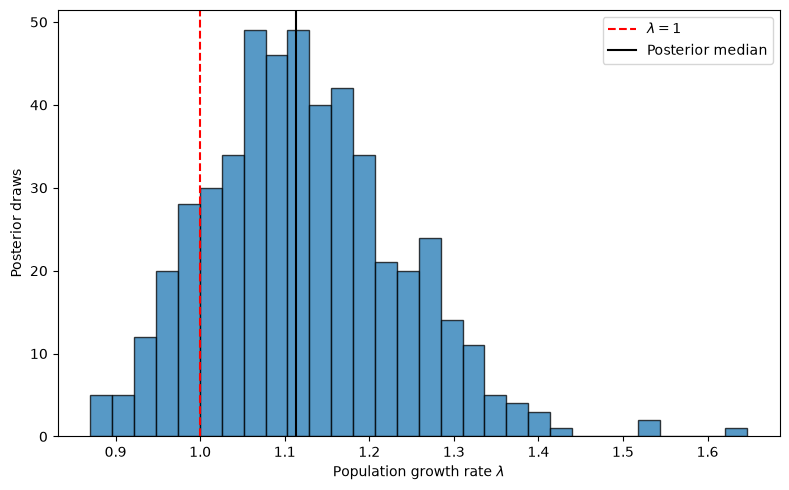

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    lambda_draws,
    bins=30,
    alpha=0.75,
    edgecolor="black",
)

plt.axvline(
    1.15,
    color="red",
    linestyle="--",
    label=r"$\lambda = 1.15 [True]$",
)

plt.axvline(
    np.median(lambda_draws),
    color="black",
    linestyle="-",
    label="Posterior median",
)

plt.xlabel(r"Population growth rate $\lambda$")
plt.ylabel("Posterior draws")
plt.legend()
plt.tight_layout()
plt.show()

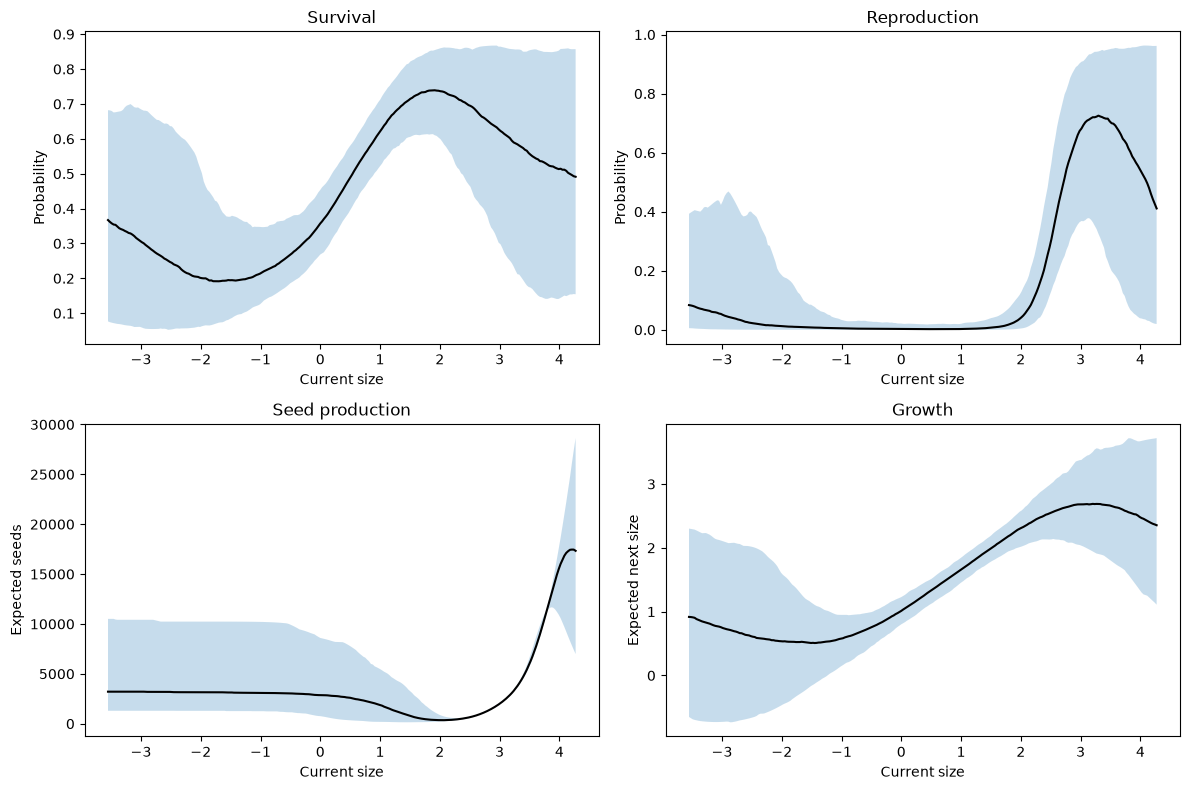

In [18]:
def plot_posterior_function(
    ax,
    mesh,
    draws,
    title,
    ylabel,
):
    median = np.median(draws, axis=0)
    lower = np.quantile(
        draws,
        0.025,
        axis=0,
    )
    upper = np.quantile(
        draws,
        0.975,
        axis=0,
    )

    ax.plot(
        mesh,
        median,
        color="black",
    )

    ax.fill_between(
        mesh,
        lower,
        upper,
        alpha=0.25,
    )

    ax.set_title(title)
    ax.set_xlabel("Current size")
    ax.set_ylabel(ylabel)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

plot_posterior_function(
    axes[0, 0],
    mesh,
    survival_draws,
    "Survival",
    "Probability",
)

plot_posterior_function(
    axes[0, 1],
    mesh,
    reproduction_draws,
    "Reproduction",
    "Probability",
)

plot_posterior_function(
    axes[1, 0],
    mesh,
    seed_draws,
    "Seed production",
    "Expected seeds",
)

plot_posterior_function(
    axes[1, 1],
    mesh,
    growth_mean_draws,
    "Growth",
    "Expected next size",
)

plt.tight_layout()
plt.show()

In [20]:
recruit_mass_exact = (
    stats.norm.cdf(
        upper_bound,
        loc=recruit_mean,
        scale=recruit_sd,
    )
    - stats.norm.cdf(
        lower_bound,
        loc=recruit_mean,
        scale=recruit_sd,
    )
)

print(
    "Recruit probability mass retained:",
    recruit_mass_exact,
)

print(
    "Recruit eviction probability:",
    1.0 - recruit_mass_exact,
)

print(
    "Median worst-case growth mass retained:",
    np.median(minimum_growth_mass_draws),
)

print(
    "2.5% quantile of worst-case growth mass retained:",
    np.quantile(
        minimum_growth_mass_draws,
        0.025,
    ),
)

Recruit probability mass retained: 0.9999985402042514
Recruit eviction probability: 1.4597957486151003e-06
Median worst-case growth mass retained: 0.9810489379800658
2.5% quantile of worst-case growth mass retained: 0.720044253698724
